## Heart Disease Prediction EDA Task
### OBJECTIVE- We try to analyse the dataset given: Heart disease, and related factors.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("Heart_dataset")
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


We will check the number of rows & colums present, the names of columns, data types and summary statistics.

In [19]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (918, 12)
Rows: 918
Columns: 12


We will see the information's datatype, the min, max and mean values.

In [20]:
df.info()
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


In [21]:
df.describe(include=["object","str"])

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


### Data cleaning and outlier detection
We will look for missing values, duplicate rows, and zeros in measurement columns. 

In [22]:
df = df.replace([" ", "NA", "N/A", ""], np.nan)
display(df.isna().sum().to_frame("missing values"))
print("Exact duplicate rows:", df.duplicated().sum())
measurement_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
print("Zero values in measurement columns:")
display((df[measurement_cols] == 0).sum().to_frame("zero values"))

,missing values
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Exact duplicate rows: 0
Zero values in measurement columns:


,zero values
Age,0
RestingBP,1
Cholesterol,172
MaxHR,0
Oldpeak,368


Outlier Detection: replacing missing/outlying data with median values.

In [23]:
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
df_original = df.copy()
df_clean = df.copy()

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    median_value = df_clean[col].median()
    print(f"{col}: replacing {mask.sum()} values with median {median_value}")
    df_clean.loc[mask, col] = median_value

Age: replacing 0 values with median 54.0
RestingBP: replacing 28 values with median 130.0
Cholesterol: replacing 183 values with median 223.0
MaxHR: replacing 2 values with median 138.0
Oldpeak: replacing 16 values with median 0.6


In [24]:
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)
df_clean["RestingBP"] = df_clean["RestingBP"].fillna(df_clean["RestingBP"].median())
df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(df_clean["Cholesterol"].median())
print(df_clean.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [25]:
print("Zero RestingBP:", (df_clean["RestingBP"] == 0).sum())
print("Zero Cholesterol:", (df_clean["Cholesterol"] == 0).sum())
print("Total missing values:", df_clean.isnull().sum().sum())

Zero RestingBP: 0
Zero Cholesterol: 0
Total missing values: 0


noting the numerical v/s categorical values.

In [26]:
numerical_columns = df_clean.select_dtypes(include=np.number).columns
categorical_columns = df_clean.select_dtypes(include=["object","str"]).columns
print("Numerical Columns:")
print(list(numerical_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


We will count the observations in each Heart Disease group. The dataset uses binary 0s and 1s.0 for not diseased and 1 for diseased.

,count
HeartDisease,
0,410
1,508


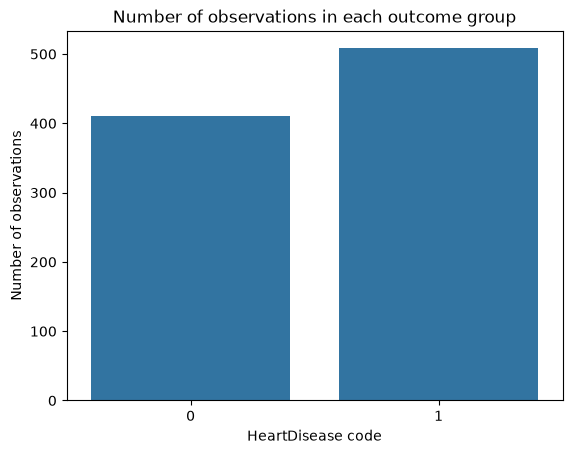

In [27]:
display(df_clean["HeartDisease"].value_counts().sort_index().to_frame("count"))
sns.countplot(data=df_clean, x="HeartDisease")
plt.title("Number of observations in each outcome group")
plt.xlabel("HeartDisease code")
plt.ylabel("Number of observations")
plt.show()

this shows the file has 410 rows coded 0 and 508 coded 1.

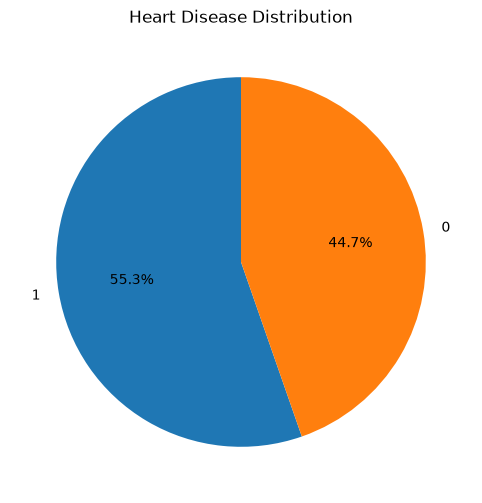

In [28]:
plt.figure(figsize=(6, 6))
df_clean["HeartDisease"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Heart Disease Distribution")
plt.show()

We will start plot the measurements.

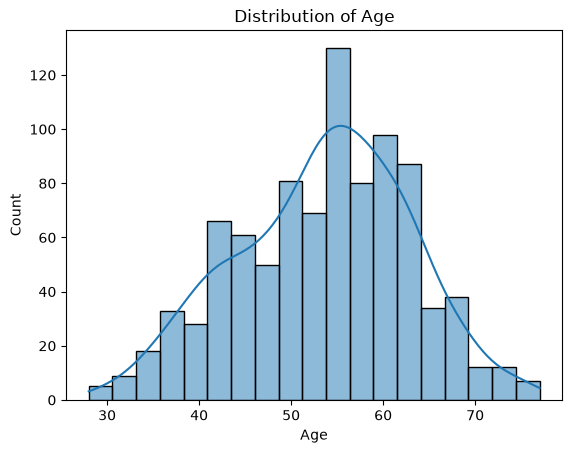

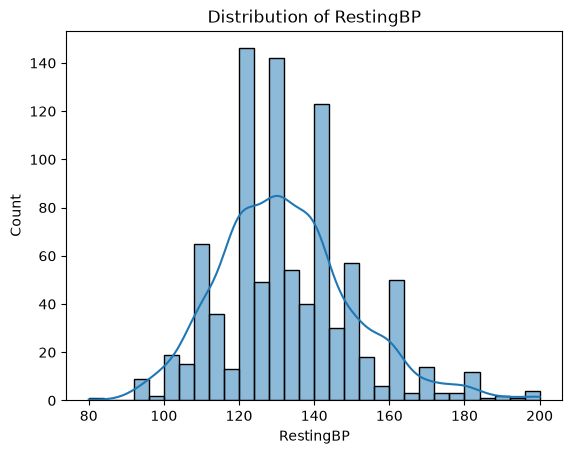

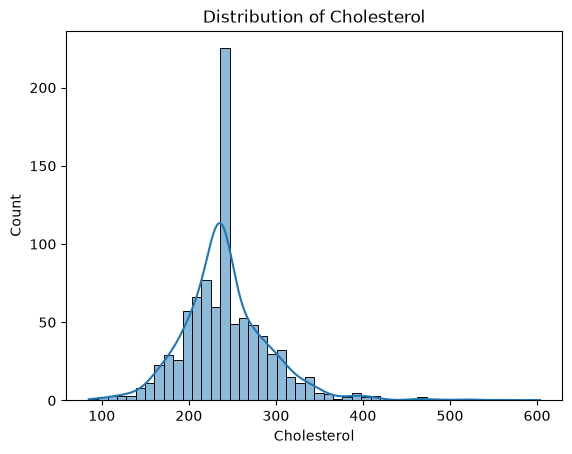

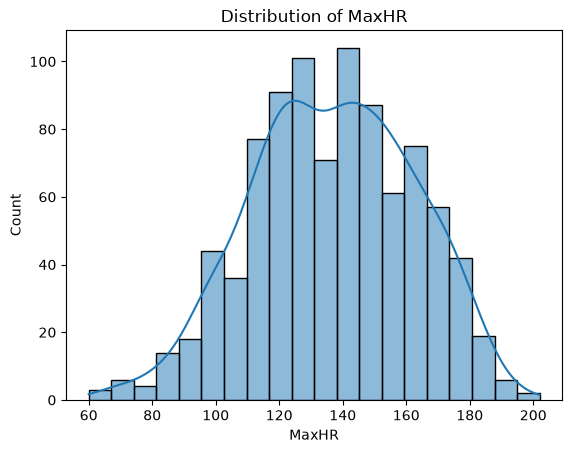

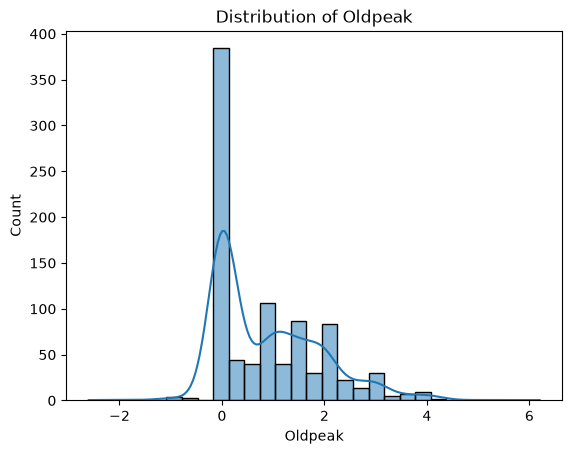

In [29]:
for col in measurement_cols:
    sns.histplot(data=df_clean, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

1. majority people in dataset are of 45-65 age group, with peak at 55.
2. majority people have resting bp in range of 120-140.
3. majority people have cholestrol ranging from 200-270.
4. maxHR plot shows two peaks, abouut 122 and 142.
5. oldpeak values atain peak at 180, has a few negative values.

### We use boxplots to compare the measurements across the two outcome groups. These plots can show differences in typical values, spread, and potential outliers. They show patterns in this dataset, not cause and effect.
Boxplots are designed to compare numeric distributions across categories.

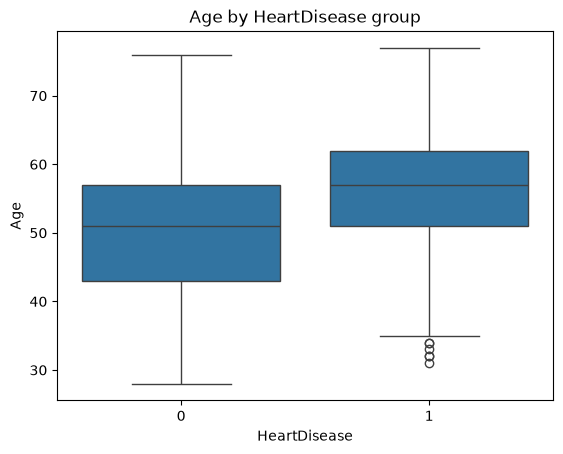

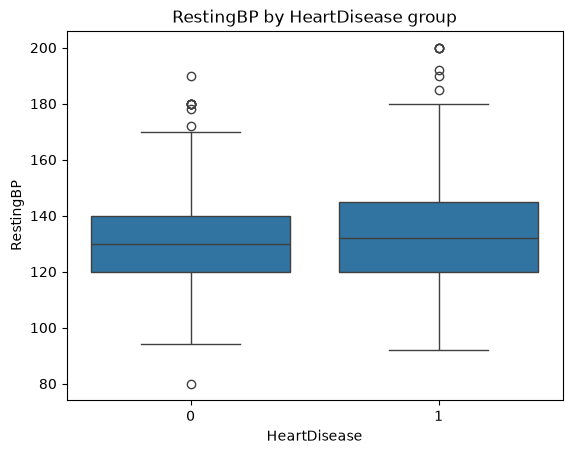

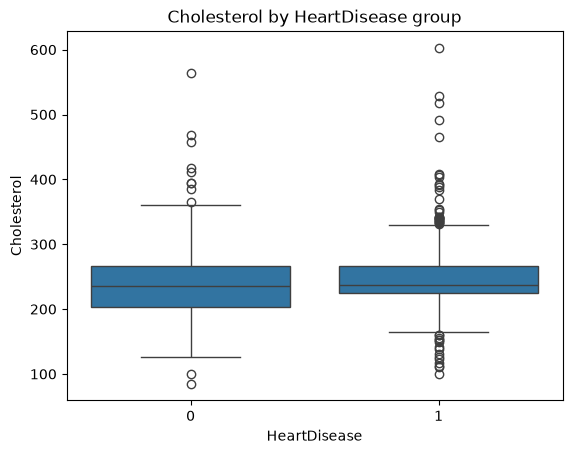

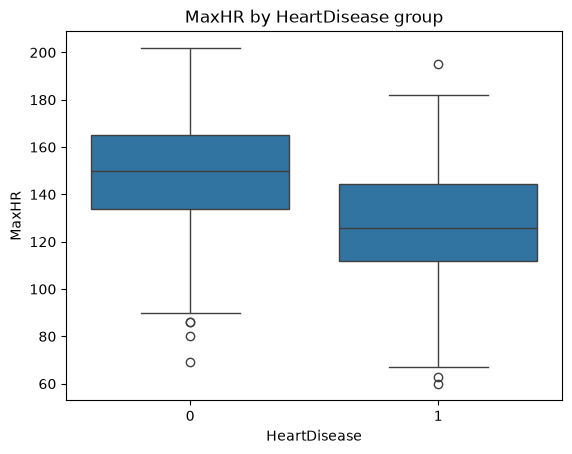

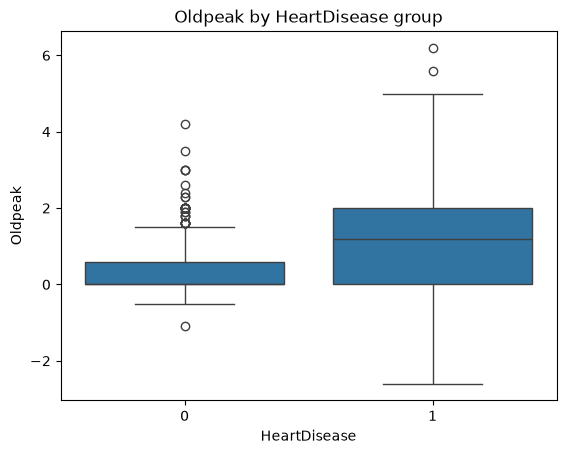

In [30]:
for col in measurement_cols:
    sns.boxplot(data=df_clean, x="HeartDisease", y=col)
    plt.title(f"{col} by HeartDisease group")
    plt.show()

1. Age: The disease group has a higher median age (about 57 v/s 51). The age ranges still overlap, so age alone does not separate the groups.
2. RestingBP: The medians and boxes are very similar. Resting blood pressure does not appear to differ much between these groups in this plot. Both groups have some unusually high or low readings.
3. Cholesterol: The medians are close, and the boxes overlap considerably. Both groups have many outliers, so this plot shows no clear separation by cholesterol alone.
4. MaxHR: The disease group has a noticeably lower median maximum heart rate (about 126 v/s 150). This is one of the clearer differences in these plots, though the groups still overlap.
5. Oldpeak: The disease group has a higher median (about 1.2 v/s 0) and a wider spread. Higher Oldpeak values are more common in the disease group in this dataset.

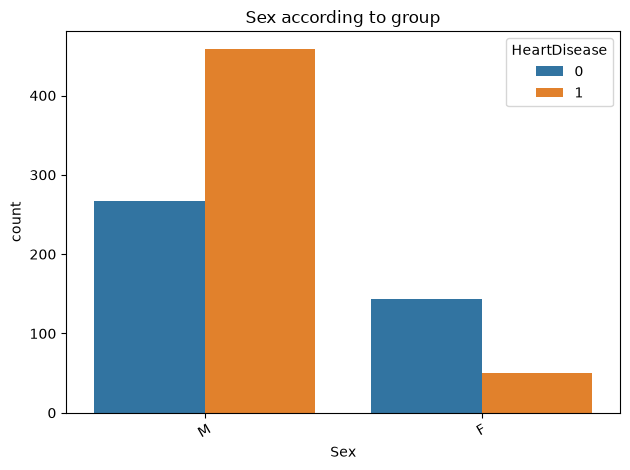

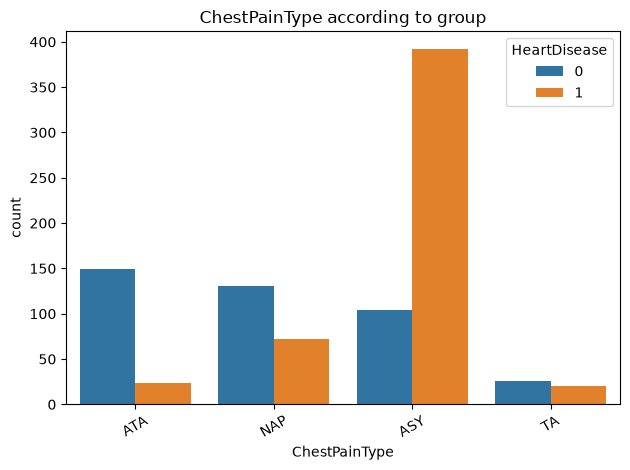

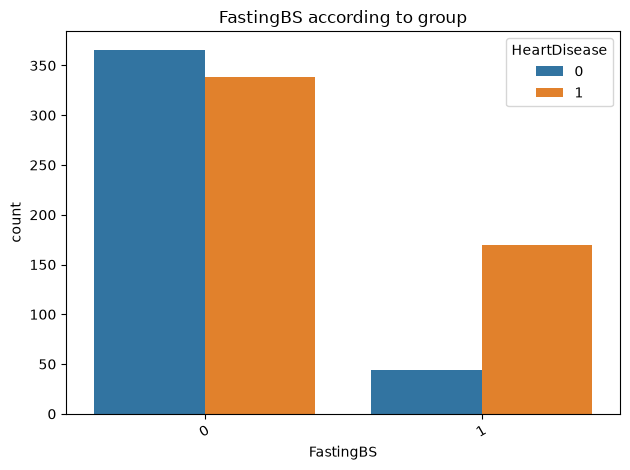

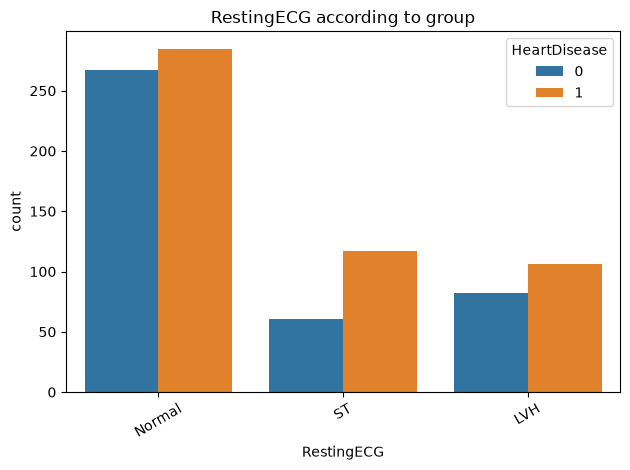

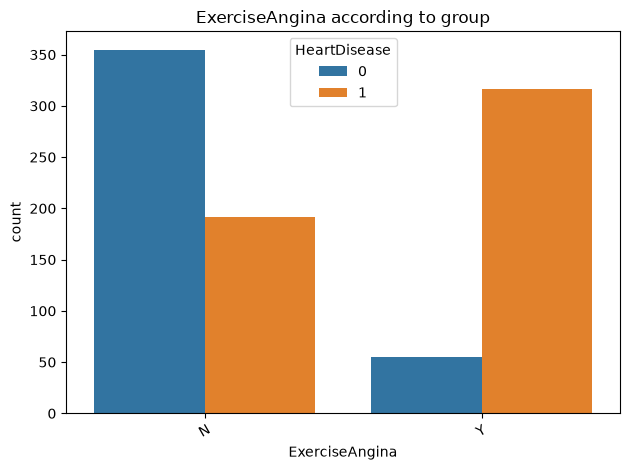

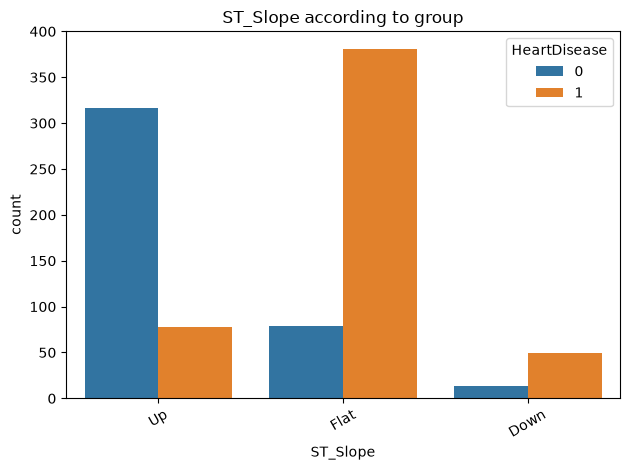

In [31]:
category_cols = ["Sex", "ChestPainType", "FastingBS","RestingECG", "ExerciseAngina", "ST_Slope"]
for col in category_cols:
    sns.countplot(data=df_clean, x=col, hue="HeartDisease")
    plt.title(f"{col} according to group")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

1. Sex: There are more male than female records overall. The disease group has many more men than women, while the no-disease group includes more women than the disease group. This dataset has a strong sex imbalance, so counts alone don’t tell us the chance of disease for each sex.
2. ChestPainType: ASY is much more common in the disease group. ATA and NAP appear more often in the no-disease group. TA counts are low in both groups.
3. FastingBS: The 1 category appears much more often in the disease group; the 0 category appears in both groups at similar counts. This suggests an association in this dataset, but the bars show counts rather than within-category rates.
4. RestingECG: ST appears more often in the disease group. Normal is common in both groups, and LVH counts are somewhat higher in the disease group. The differences are less dramatic than in some other charts.
5. ExerciseAngina: The Y category is mostly in the disease group, while N is more common in the no-disease group. This is a clear difference in these counts.
6. ST_Slope: Flat is much more common in the disease group, while Up is much more common in the no-disease group. Down has relatively few records.

### The heatmap can help identify numeric features that vary together, whereas Correlation does not show that one feature causes another.

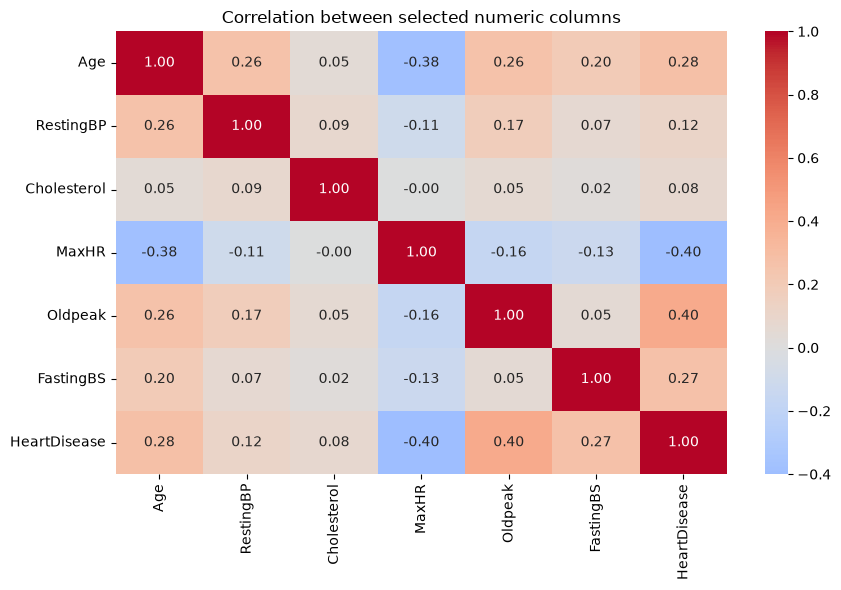

In [32]:
correlation_cols = measurement_cols + ["FastingBS", "HeartDisease"]
correlations = df_clean[correlation_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlations,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation between selected numeric columns")
plt.tight_layout()
plt.show()

-1:negative correlation, +1:positive correlation, 0:no correlation
1. Oldpeak: +0.40 - higher Oldpeak tends to occur alongside HeartDisease
2. MaxHR: -0.40 - lower maximum heart rate tends to occur alongside HeartDisease
3. Age: +0.28 and FastingBS: +0.27 - weaker positive relationships.
4. RestingBP: +0.12 and Cholesterol: +0.08 - very weak relationships in this heatmap.

## Findings:
1. The dataset has 918 rows and 12 columns.
2. The "HeartDisease" outcome counts are 410 rows coded 0 and 508 coded 1.
3. Missing values or duplicate rows: 0.
4. Measurement distributions that stood out:

- Age: The HeartDisease = 1 group is older on average in the boxplot, though the age ranges overlap.
- MaxHR: The disease group has a noticeably lower median maximum heart rate. The heatmap also shows a moderate negative correlation with HeartDisease (−0.40).
- Oldpeak: Values tend to be higher and more spread out in the disease group. It has a moderate positive correlation with HeartDisease (+0.40).
- Chest pain: ASY is much more common in the disease group; ATA and NAP appear more often in the no-disease group.
- Exercise-induced angina: “Y” is much more common in the disease group, while “N” is more common in the no-disease group.
- ST slope: Flat appears much more often in the disease group; Up appears much more often in the no-disease group.
- Fasting blood sugar: The value 1 appears more often in the disease group. Its heatmap correlation with HeartDisease is weaker (+0.27).
- Resting blood pressure and cholesterol: Their boxplots overlap substantially between groups, and their correlations with HeartDisease are weak in this dataset.
- Resting ECG: ST appears more often in the disease group; Normal occurs frequently in both groups.
- Correlated measurements: Larger engine-independent clinical values? Among the heart features, age tends to accompany lower MaxHR. (This finding is from the heatmap.)